In [1]:
# ch04_TOOL_AND_MEMORY.ipynb

In [3]:
!uv pip list

Package                  Version
------------------------ -----------
aiohappyeyeballs         2.6.2
aiohttp                  3.14.0
aiosignal                1.4.0
annotated-types          0.7.0
anyio                    4.13.0
appnope                  0.1.4
asttokens                3.0.1
attrs                    26.1.0
boto3                    1.42.89
botocore                 1.42.97
certifi                  2026.5.20
cffi                     2.0.0
charset-normalizer       3.4.7
comm                     0.2.3
cryptography             48.0.0
debugpy                  1.8.21
decorator                5.3.1
distro                   1.9.0
executing                2.2.1
filetype                 1.2.0
frozenlist               1.8.0
google-auth              2.53.0
google-genai             2.8.0
h11                      0.16.0
httpcore                 1.0.9
httpx                    0.28.1
httpx-sse                0.4.3
idna                     3.18
ipykernel                7.2.0
ipython         

In [4]:
!pip3 list

Package                   Version
------------------------- --------------
aiohappyeyeballs          2.6.1
aiohttp                   3.13.5
aiosignal                 1.4.0
altair                    5.5.0
annotated-types           0.7.0
anthropic                 0.95.0
anyio                     4.7.0
appnope                   0.1.4
argon2-cffi               23.1.0
argon2-cffi-bindings      21.2.0
arrow                     1.3.0
asttokens                 3.0.0
async-lru                 2.0.4
attrs                     24.2.0
babel                     2.16.0
beautifulsoup4            4.12.3
bleach                    6.2.0
blinker                   1.9.0
boto3                     1.42.89
botocore                  1.42.89
cachetools                5.5.0
certifi                   2024.7.4
cffi                      1.17.1
charset-normalizer        2.0.12
click                     8.1.7
coloredlogs               15.0.1
comm                      0.2.2
dataclasses-json          0.6.7
debugpy     

In [5]:
from dotenv import load_dotenv
load_dotenv()

True

In [7]:
#!pip install -U langchain-tavily
from langchain_tavily import TavilySearch

In [8]:
tool = TavilySearch(max_results=2)
tools = [tool]

In [9]:
tool.invoke("랭그래프에서 '노드'란 무엇인가요?")

{'query': "랭그래프에서 '노드'란 무엇인가요?",
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://wikidocs.net/261580',
   'title': '1-3-3. 노드 (Node) - LangGraph 가이드북',
   'content': 'LangGraph에서 노드(Node)는 실제 작업을 수행하는 핵심 단위입니다. 각 노드는 Python 함수로 구현되며, 현재 상태를 입력받아 처리하고 업데이트된 상태를 반환',
   'score': 0.99942964,
   'raw_content': None},
  {'url': 'https://kr.linkedin.com/pulse/langgraph-nodes-agents-multi-agent-composition-walid-negm-kaxwe?tl=ko',
   'title': '🧠 랭그래프 — 노드, 에이전트, 그리고 다중 에이전트 구성',
   'content': '그래프 내 각 노드 (또는 워크플로우) 연산을 수행합니다 — 예를 들어 추론, 도구 호출, 라우팅 논리 적용 — 가장자리 상태와 메시지가 어떻게 이동하는지',
   'score': 0.998487,
   'raw_content': None}],
 'response_time': 0.78,
 'request_id': '0c028f67-c1cf-4f72-99f8-9d3b1120df5f'}

In [11]:
from langchain.chat_models import init_chat_model
import os
#llm = init_chat_model("openai:gpt-4.1")
llm = init_chat_model(
    model=f"google_genai:{os.getenv('GEMINI_MODEL')}",
    api_key=os.getenv('GEMINI_API_KEY'),
)
llm_with_tools = llm.bind_tools(tools)

In [12]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [13]:
graph_builder.add_node("chatbot", chatbot)

In [14]:
import json
from langchain_core.messages import ToolMessage

class BasicToolNode:
    """챗봇이 요청한 도구를 실행하는 노드입니다."""

    def __init__(self, tools: list):
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        messages = inputs.get("messages", [])
        if not messages:
            raise ValueError("입력된 상태에서 메시지를 찾을 수 없습니다.")

        outputs = []
        for tool_call in messages[-1].tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(tool_call["args"])
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"]
                )
            )
        return {"messages": outputs}

tool_node = BasicToolNode(tools=[tool])

In [15]:
from langgraph.prebuilt import ToolNode

tool_node = ToolNode(tools=[tool])

In [16]:
graph_builder.add_node("tools", tool_node)

In [17]:
def route_tools(state: State):
    """
    마지막 챗봇 메시지에서 도구 호출(tool_calls)이 있는지 확인하여
    있으면 'tools' 노드로, 없으면 종료(END)로 이동합니다.
    """
    ai_message = state["messages"][-1]

    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"  # 도구 호출이 있으면 도구 노드로 이동
    return END  # 도구 호출이 없으면 종료

graph_builder.add_conditional_edges(
    "chatbot",
    route_tools,
    {"tools": "tools", END: END}
)

In [18]:
from langgraph.prebuilt import tools_condition

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition
)

In [19]:
# 도구 호출 후 챗봇으로 돌아가는 경로 설정
graph_builder.add_edge("tools", "chatbot")

# 그래프의 시작점 설정
graph_builder.add_edge(START, "chatbot")

# 그래프 완성 및 컴파일
graph = graph_builder.compile()

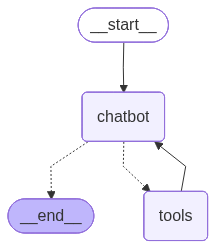

In [20]:
from IPython.display import Image, display

try:
    # Mermaid 기반으로 생성된 PNG 그래프를 출력
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # 시각화에 필요한 의존성 패키지가 없다면 예외 처리
    pass

In [21]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

In [23]:
while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break

    stream_graph_updates(user_input)

User:  exit


Goodbye!


In [43]:
# MEMORY

In [24]:
from dotenv import load_dotenv
load_dotenv()

True

In [25]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [26]:
graph = graph_builder.compile(checkpointer=memory)

In [29]:
config = {"configurable": {"thread_id": "1"}}
#user_input = "안녕하세요! 제 이름은 랭체인입니다."
user_input = "랭그래프에서 엣지의 의미"

events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values"
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

랭그래프에서 엣지의 의미
================================== Ai Message ==================================
Tool Calls:
  tavily_search (95bcaf10-5ee1-4ba8-9375-756b859e926e)
 Call ID: 95bcaf10-5ee1-4ba8-9375-756b859e926e
  Args:
    query: LangGraph edges meaning
================================= Tool Message =================================
Name: tavily_search

{"query": "LangGraph edges meaning", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://dev.to/aiengineering/a-beginners-guide-to-getting-started-on-edges-in-langgraph-59be", "title": "A Beginner’s Guide to Getting Started on Edges in LangGraph - DEV Community", "content": "Cover image for A Beginner’s Guide to Getting Started on Edges in LangGraph. # A Beginner’s Guide to Getting Started on Edges in LangGraph. If you’ve been following this LangGraph series, you already know we’ve covered a lot of ground: **nodes**, **sta

In [28]:
user_input = "내 이름이 뭐였나요?"

events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values"
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

내 이름이 뭐였나요?
================================== Ai Message ==================================

랭체인님이시군요!


In [49]:
snapshot = graph.get_state(config)
print(snapshot)

StateSnapshot(values={'messages': [HumanMessage(content='안녕하세요! 제 이름은 랭체인입니다.', additional_kwargs={}, response_metadata={}, id='d34c954c-ae3b-40de-aa05-98210571f814'), AIMessage(content='안녕하세요, 랭체인님! 만나서 반갑습니다. 어떤 도움이 필요하신가요? 궁금한 점이 있으면 언제든 말씀해 주세요! 😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 1199, 'total_tokens': 1237, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_1a2c4a5ede', 'id': 'chatcmpl-CzKl2w2fRtgikAHGLxUTDSOJoNWvB', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019bd0c0-8248-7e90-9d91-2a0e7fa2abbf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1199, 'output_tokens': 38, 'total_tokens': 1237, 'inp

In [50]:
snapshot.next  # 다음 실행될 노드 (대화가 끝났다면 빈 튜플)

()

In [51]:
snapshot.values  # 현재까지의 메시지 리스트

{'messages': [HumanMessage(content='안녕하세요! 제 이름은 랭체인입니다.', additional_kwargs={}, response_metadata={}, id='d34c954c-ae3b-40de-aa05-98210571f814'),
  AIMessage(content='안녕하세요, 랭체인님! 만나서 반갑습니다. 어떤 도움이 필요하신가요? 궁금한 점이 있으면 언제든 말씀해 주세요! 😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 1199, 'total_tokens': 1237, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_1a2c4a5ede', 'id': 'chatcmpl-CzKl2w2fRtgikAHGLxUTDSOJoNWvB', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019bd0c0-8248-7e90-9d91-2a0e7fa2abbf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1199, 'output_tokens': 38, 'total_tokens': 1237, 'input_token_details': 